In [1]:
# CELL 1: IMPORT LIBRARIES, PATHS AND LOAD DATA

import pandas as pd
import matplotlib.pyplot as plt
import os

BASE_PATH = ".."

TRANS_PATH = os.path.join(
    BASE_PATH, "data", "raw", "LI-Small_Trans.csv"
)

GRAPH_PATH = os.path.join(
    BASE_PATH, "graphs", "dataset"
)

# Create graph output folder if it does not exist
os.makedirs(GRAPH_PATH, exist_ok=True)

# Load transactions
trans_df = pd.read_csv(TRANS_PATH)

# Create laundering subset
laundering_df = trans_df[
    trans_df["Is Laundering"] == 1
].copy()

print("Transactions:", trans_df.shape)
print("Laundering transactions:", laundering_df.shape)

print("\nGraph output folder:")
print(GRAPH_PATH)

Transactions: (6924049, 11)
Laundering transactions: (3565, 11)

Graph output folder:
..\graphs\dataset


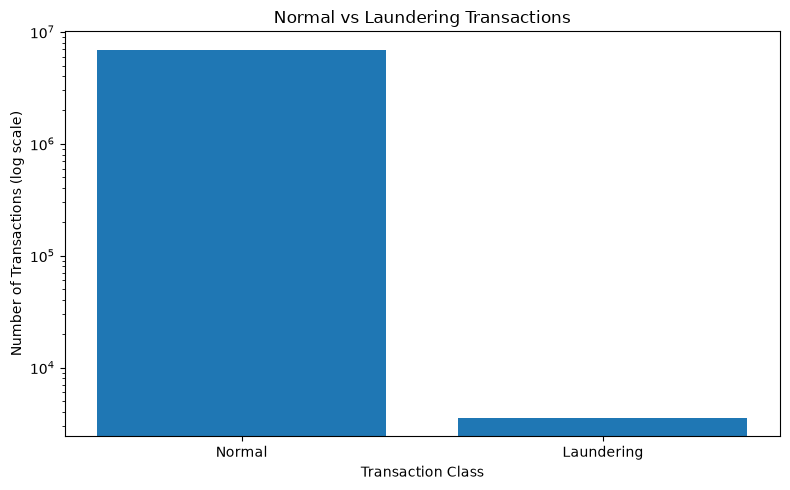

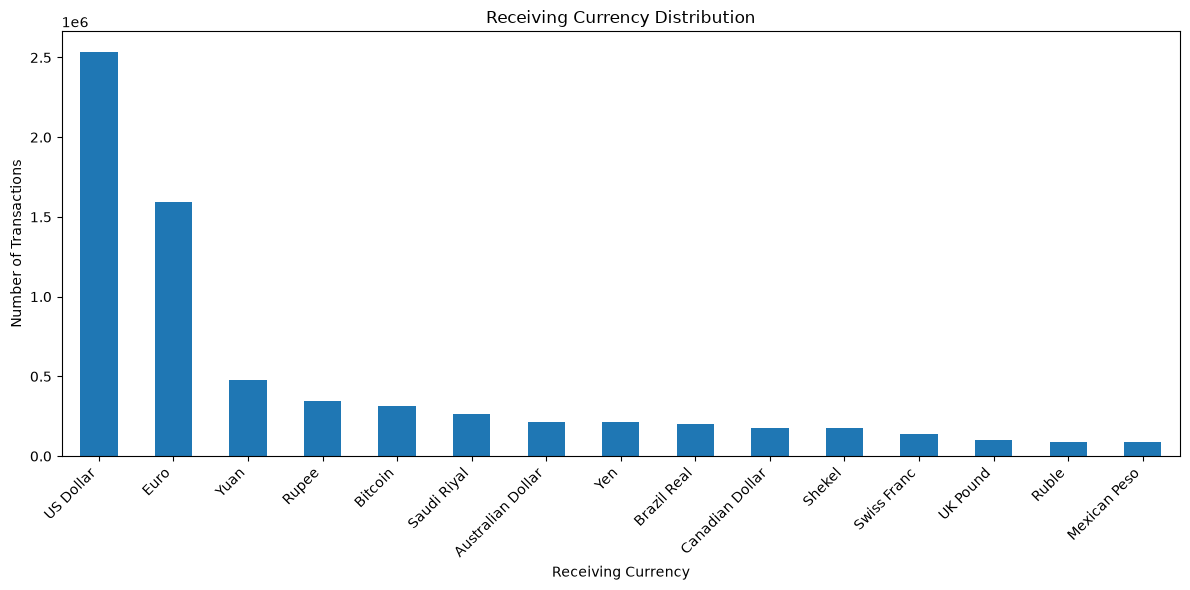

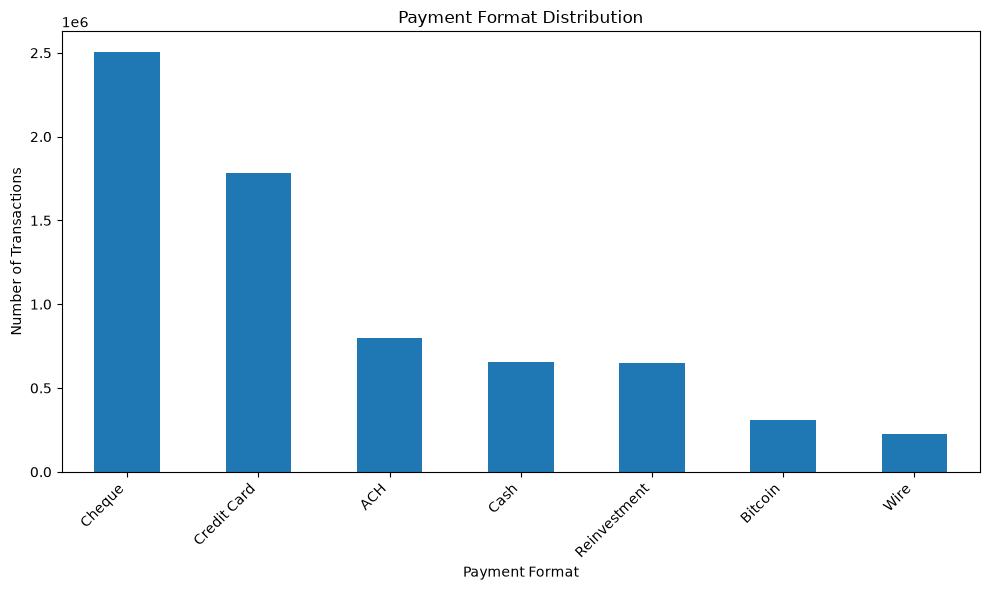

In [2]:
# CELL 2: OVERALL DATASET DISTRIBUTIONS

# ---------------------------------------------------------
# 1. Normal vs Laundering
# ---------------------------------------------------------

class_counts = trans_df["Is Laundering"].value_counts().sort_index()

labels = ["Normal", "Laundering"]

plt.figure(figsize=(8, 5))
plt.bar(labels, class_counts.values)
plt.yscale("log")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions (log scale)")
plt.title("Normal vs Laundering Transactions")
plt.tight_layout()

plt.savefig(
    os.path.join(GRAPH_PATH, "01_normal_vs_laundering.png"),
    dpi=300
)

plt.show()


# ---------------------------------------------------------
# 2. Receiving Currency
# ---------------------------------------------------------

currency_counts = (
    trans_df["Receiving Currency"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
currency_counts.plot(kind="bar")
plt.xlabel("Receiving Currency")
plt.ylabel("Number of Transactions")
plt.title("Receiving Currency Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    os.path.join(GRAPH_PATH, "02_receiving_currency.png"),
    dpi=300
)

plt.show()


# ---------------------------------------------------------
# 3. Payment Format
# ---------------------------------------------------------

payment_counts = (
    trans_df["Payment Format"]
    .value_counts()
)

plt.figure(figsize=(10, 6))
payment_counts.plot(kind="bar")
plt.xlabel("Payment Format")
plt.ylabel("Number of Transactions")
plt.title("Payment Format Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    os.path.join(GRAPH_PATH, "03_payment_format.png"),
    dpi=300
)

plt.show()

Same Bank / Cross Bank:
Cross Bank    6012046
Same Bank      912003
Name: count, dtype: int64


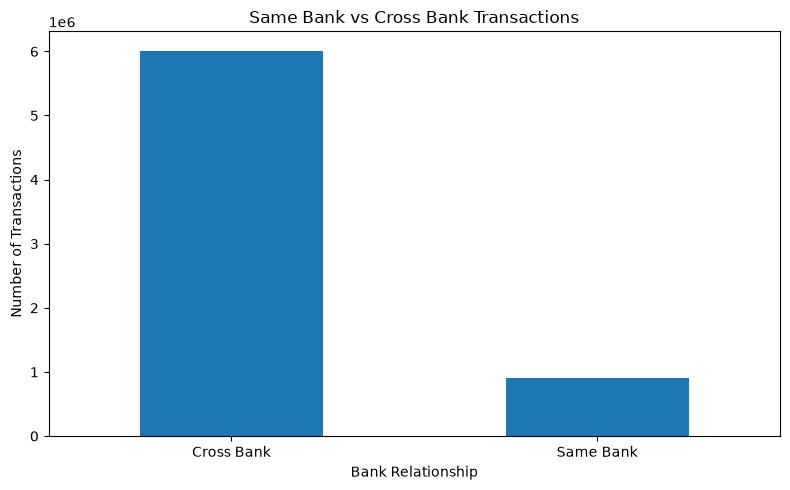


Self Transactions:
Different Accounts    6119572
Self Transaction       804477
Name: count, dtype: int64


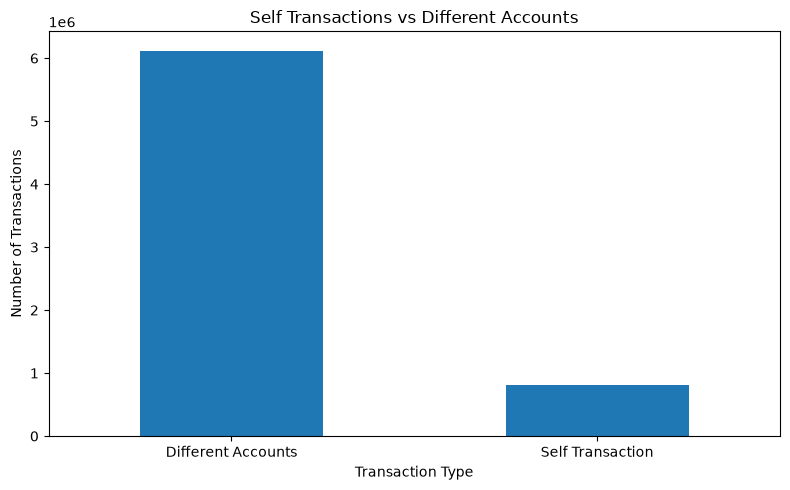

In [3]:
# CELL 3: BANK AND ACCOUNT RELATIONSHIP ANALYSIS

# ---------------------------------------------------------
# Same Bank vs Cross Bank
# ---------------------------------------------------------

same_bank = trans_df["From Bank"] == trans_df["To Bank"]

bank_relationship = pd.Series(
    ["Same Bank" if x else "Cross Bank" for x in same_bank]
).value_counts()

print("Same Bank / Cross Bank:")
print(bank_relationship)

plt.figure(figsize=(8, 5))
bank_relationship.plot(kind="bar")

plt.xlabel("Bank Relationship")
plt.ylabel("Number of Transactions")
plt.title("Same Bank vs Cross Bank Transactions")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(GRAPH_PATH, "04_same_vs_cross_bank.png"),
    dpi=300
)

plt.show()


# ---------------------------------------------------------
# Self Transactions
# ---------------------------------------------------------

self_transaction = (
    (trans_df["From Bank"] == trans_df["To Bank"]) &
    (trans_df["Account"] == trans_df["Account.1"])
)

self_counts = pd.Series(
    ["Self Transaction" if x else "Different Accounts"
     for x in self_transaction]
).value_counts()

print("\nSelf Transactions:")
print(self_counts)

plt.figure(figsize=(8, 5))
self_counts.plot(kind="bar")

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.title("Self Transactions vs Different Accounts")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(GRAPH_PATH, "05_self_vs_different_accounts.png"),
    dpi=300
)

plt.show()

<Figure size 1100x600 with 0 Axes>

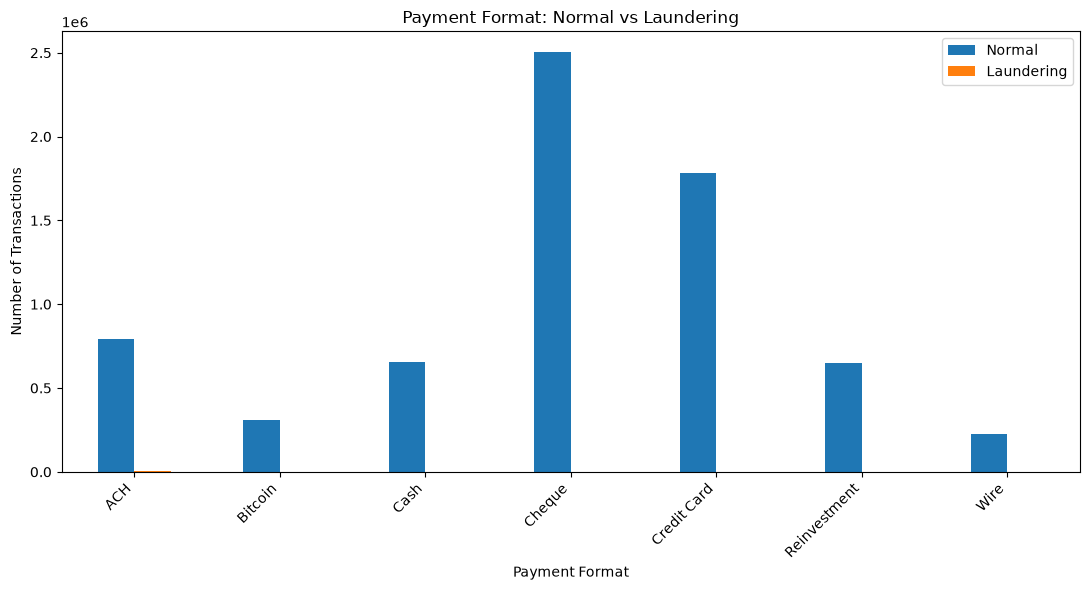

<Figure size 1400x700 with 0 Axes>

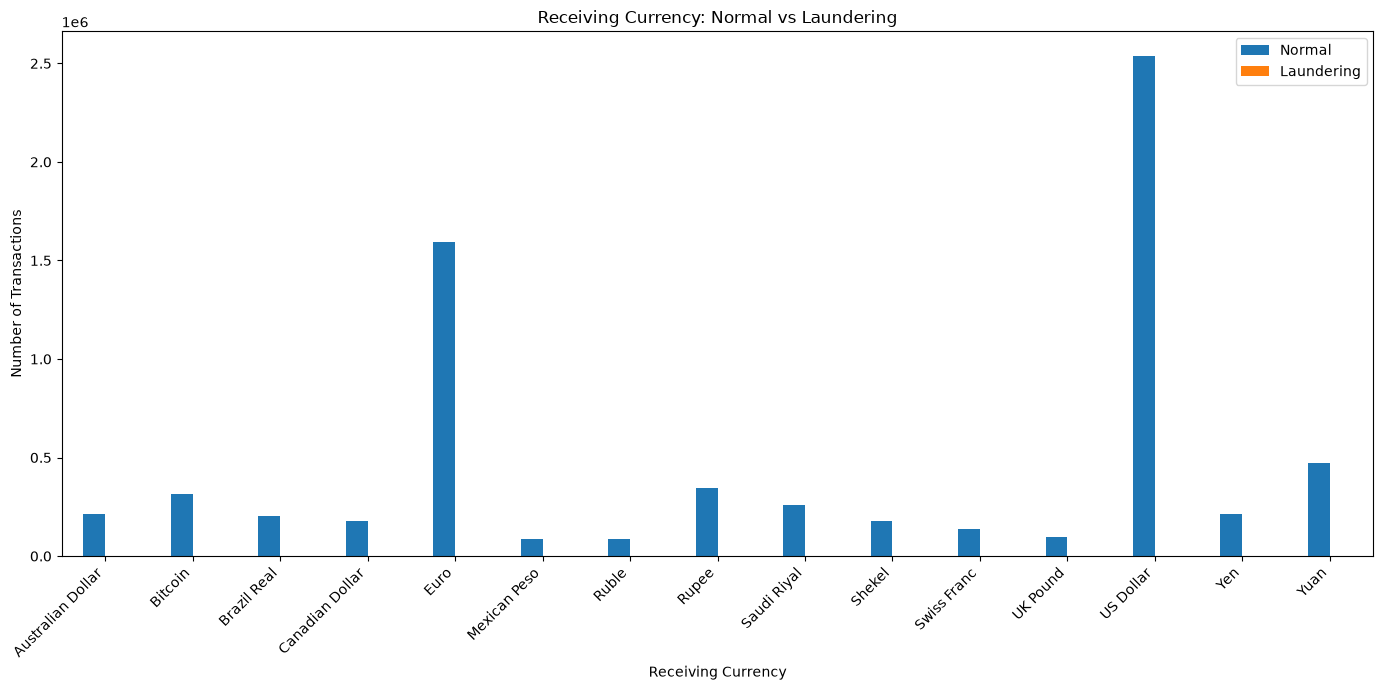

In [4]:
# CELL 4: NORMAL VS LAUNDERING COMPARISONS

# ---------------------------------------------------------
# Payment Format
# ---------------------------------------------------------

payment_comparison = pd.crosstab(
    trans_df["Payment Format"],
    trans_df["Is Laundering"]
)

payment_comparison.columns = [
    "Normal" if col == 0 else "Laundering"
    for col in payment_comparison.columns
]

plt.figure(figsize=(11, 6))
payment_comparison.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Payment Format")
plt.ylabel("Number of Transactions")
plt.title("Payment Format: Normal vs Laundering")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "06_payment_format_normal_vs_laundering.png"
    ),
    dpi=300
)

plt.show()


# ---------------------------------------------------------
# Receiving Currency
# ---------------------------------------------------------

currency_comparison = pd.crosstab(
    trans_df["Receiving Currency"],
    trans_df["Is Laundering"]
)

currency_comparison.columns = [
    "Normal" if col == 0 else "Laundering"
    for col in currency_comparison.columns
]

plt.figure(figsize=(14, 7))
currency_comparison.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.xlabel("Receiving Currency")
plt.ylabel("Number of Transactions")
plt.title("Receiving Currency: Normal vs Laundering")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "07_currency_normal_vs_laundering.png"
    ),
    dpi=300
)

plt.show()

LAUNDERING TRANSACTION PROFILE
Rows: 3565
Unique source accounts: 2382
Unique destination accounts: 3304
Unique source banks: 968
Unique destination banks: 1187

Payment Formats:
Payment Format
ACH            2611
Cheque          459
Credit Card     261
Cash            124
Bitcoin         110
Name: count, dtype: int64

Receiving Currencies:
Receiving Currency
US Dollar            1456
Euro                 1025
Yuan                  189
Saudi Riyal           115
Rupee                 112
Bitcoin               110
Yen                    86
Canadian Dollar        86
Australian Dollar      77
Brazil Real            72
Shekel                 65
Swiss Franc            56
UK Pound               40
Ruble                  39
Mexican Peso           37
Name: count, dtype: int64


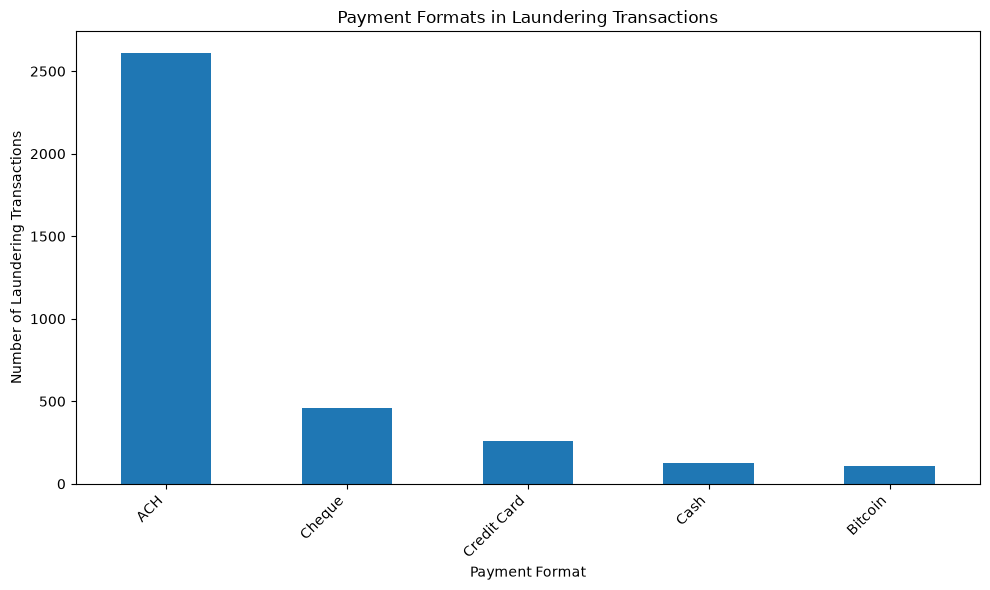

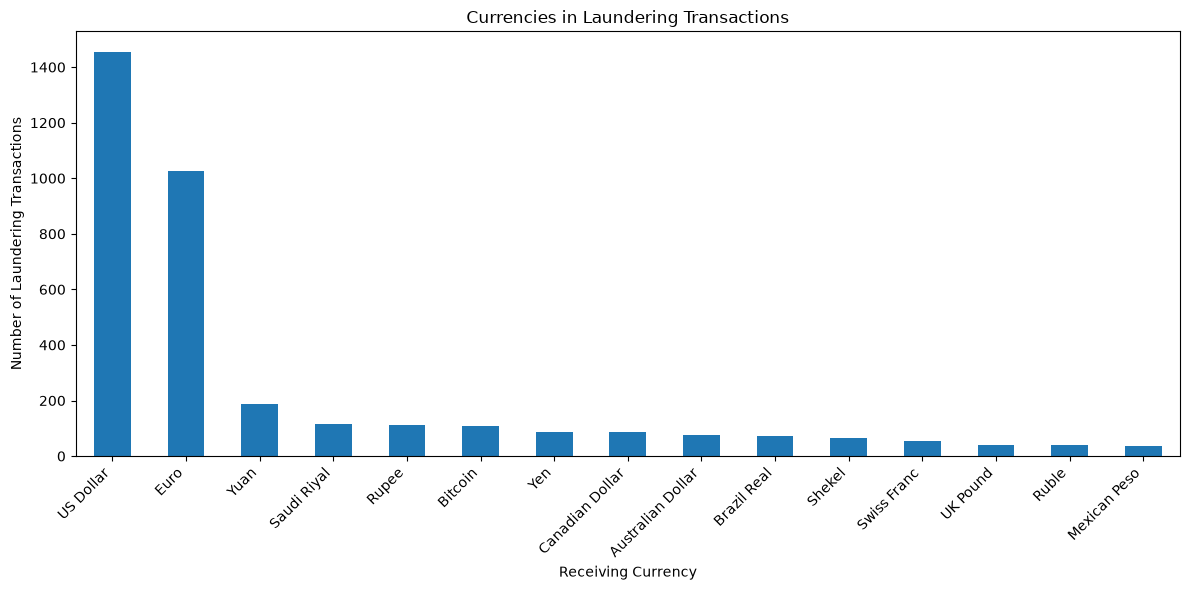


Laundering Same/Cross Bank:
Cross Bank    3492
Same Bank       73
Name: count, dtype: int64


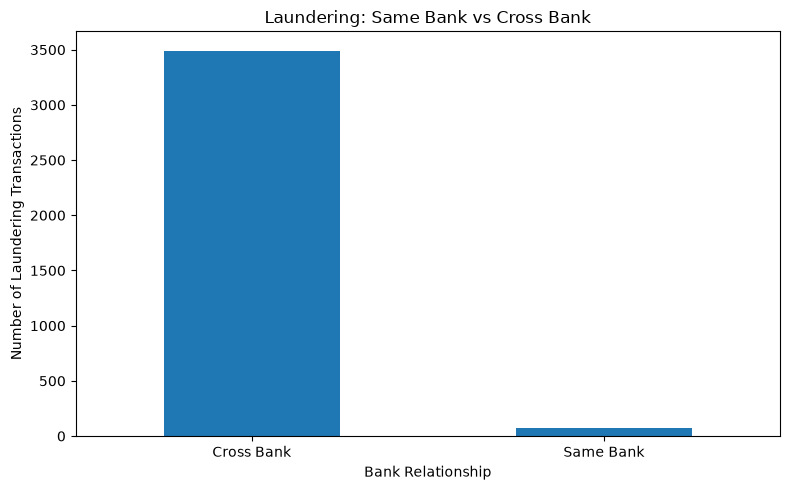


Laundering Self Transactions:
Different Accounts    3562
Self Transaction         3
Name: count, dtype: int64


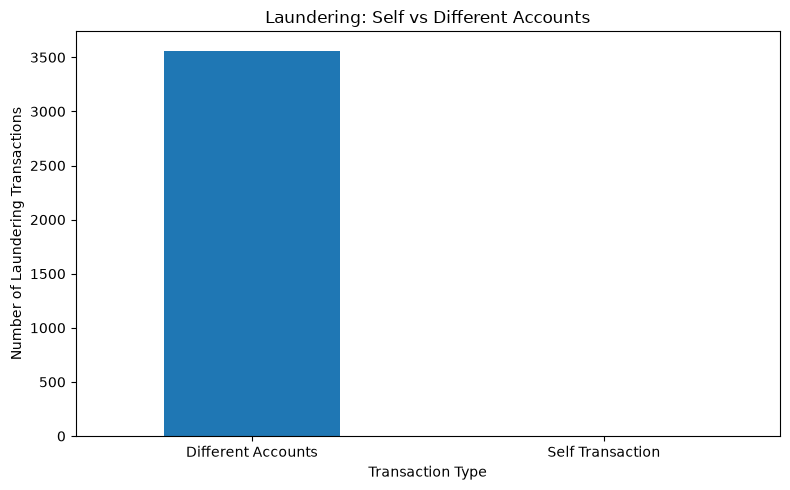

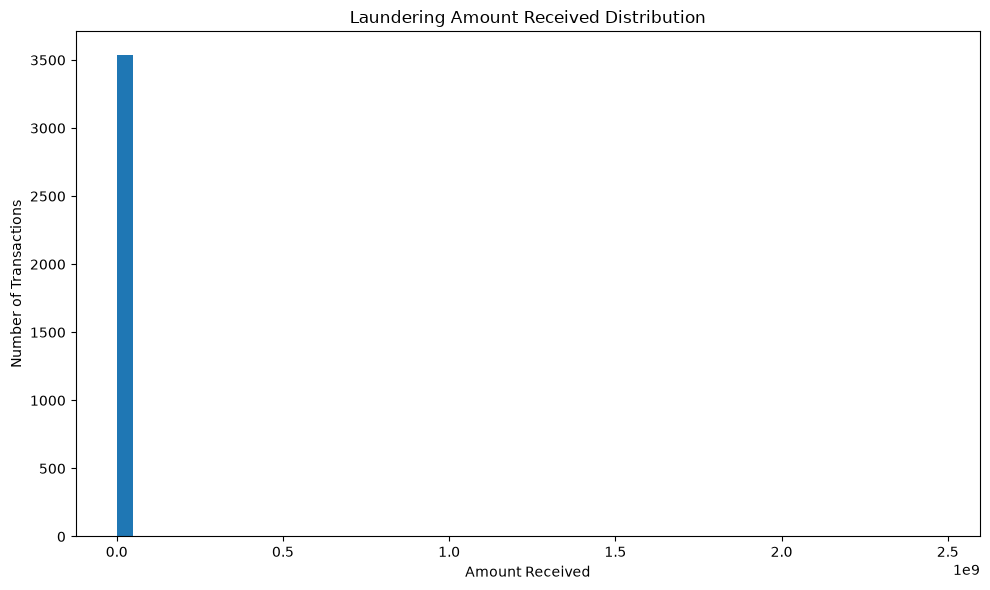

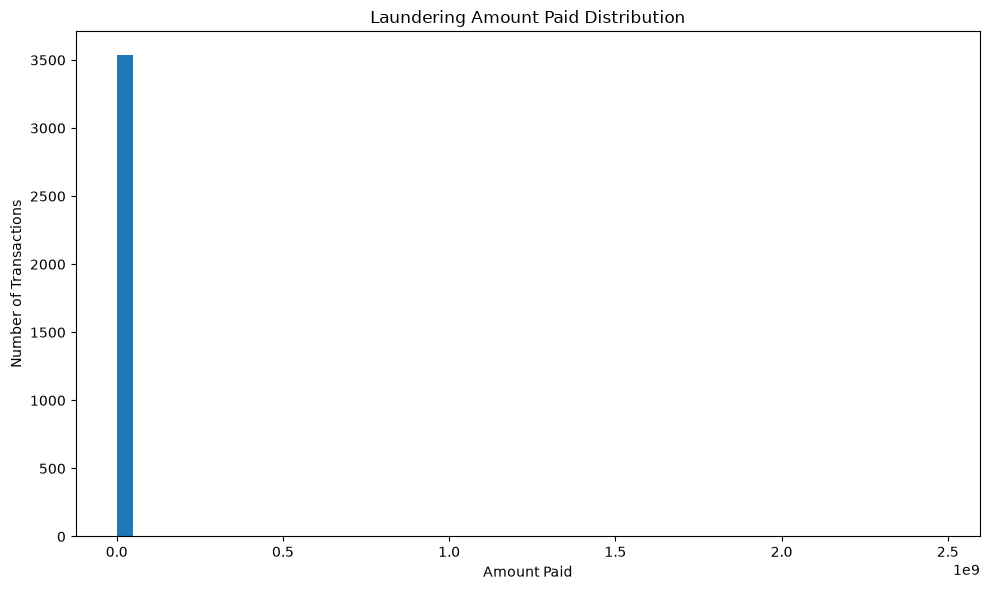


All dataset graphs saved to:
..\graphs\dataset


In [5]:
# CELL 5: LAUNDERING-ONLY DATASET ANALYSIS

print("LAUNDERING TRANSACTION PROFILE")
print("=" * 60)

print("Rows:", len(laundering_df))

print(
    "Unique source accounts:",
    laundering_df["Account"].nunique()
)

print(
    "Unique destination accounts:",
    laundering_df["Account.1"].nunique()
)

print(
    "Unique source banks:",
    laundering_df["From Bank"].nunique()
)

print(
    "Unique destination banks:",
    laundering_df["To Bank"].nunique()
)

print("\nPayment Formats:")
print(laundering_df["Payment Format"].value_counts())

print("\nReceiving Currencies:")
print(laundering_df["Receiving Currency"].value_counts())


# ---------------------------------------------------------
# Laundering Payment Format
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
laundering_df["Payment Format"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Payment Format")
plt.ylabel("Number of Laundering Transactions")
plt.title("Payment Formats in Laundering Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "08_laundering_payment_format.png"
    ),
    dpi=300
)

plt.show()


# ---------------------------------------------------------
# Laundering Currency
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))
laundering_df["Receiving Currency"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Receiving Currency")
plt.ylabel("Number of Laundering Transactions")
plt.title("Currencies in Laundering Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "09_laundering_currency.png"
    ),
    dpi=300
)

plt.show()


# ---------------------------------------------------------
# Laundering Same/Cross Bank
# ---------------------------------------------------------

laundering_same_bank = (
    laundering_df["From Bank"] ==
    laundering_df["To Bank"]
)

laundering_bank_type = pd.Series(
    [
        "Same Bank" if x else "Cross Bank"
        for x in laundering_same_bank
    ]
).value_counts()

print("\nLaundering Same/Cross Bank:")
print(laundering_bank_type)

plt.figure(figsize=(8, 5))
laundering_bank_type.plot(kind="bar")

plt.xlabel("Bank Relationship")
plt.ylabel("Number of Laundering Transactions")
plt.title("Laundering: Same Bank vs Cross Bank")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "10_laundering_same_vs_cross_bank.png"
    ),
    dpi=300
)

plt.show()


# ---------------------------------------------------------
# Laundering Self Transactions
# ---------------------------------------------------------

laundering_self = (
    (laundering_df["From Bank"] ==
     laundering_df["To Bank"]) &
    (laundering_df["Account"] ==
     laundering_df["Account.1"])
)

laundering_self_type = pd.Series(
    [
        "Self Transaction" if x else "Different Accounts"
        for x in laundering_self
    ]
).value_counts()

print("\nLaundering Self Transactions:")
print(laundering_self_type)

plt.figure(figsize=(8, 5))
laundering_self_type.plot(kind="bar")

plt.xlabel("Transaction Type")
plt.ylabel("Number of Laundering Transactions")
plt.title("Laundering: Self vs Different Accounts")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "11_laundering_self_transactions.png"
    ),
    dpi=300
)

plt.show()


# ---------------------------------------------------------
# Amount Distributions
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.hist(
    laundering_df["Amount Received"],
    bins=50
)

plt.xlabel("Amount Received")
plt.ylabel("Number of Transactions")
plt.title("Laundering Amount Received Distribution")
plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "12_laundering_amount_received.png"
    ),
    dpi=300
)

plt.show()


plt.figure(figsize=(10, 6))
plt.hist(
    laundering_df["Amount Paid"],
    bins=50
)

plt.xlabel("Amount Paid")
plt.ylabel("Number of Transactions")
plt.title("Laundering Amount Paid Distribution")
plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPH_PATH,
        "13_laundering_amount_paid.png"
    ),
    dpi=300
)

plt.show()

print("\nAll dataset graphs saved to:")
print(GRAPH_PATH)